## Fine-tune an LLM for a closed-domain (contextual) question-answering task on SQuAD dataset. Benchmark using different PEFT approaches

In [1]:
!pip install datasets==2.14.5 evaluate==0.4.0 fsspec==2023.6.0

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 11.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Suc

In [2]:
!pip install transformers datasets peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.10.19
    Uninstalling nvidia-curand-cu12-

In [3]:
!pip install git+https://github.com/huggingface/peft.git

  Cloning https://github.com/huggingface/peft.git to /tmp/pip-req-build-o2y574ep
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft.git /tmp/pip-req-build-o2y574ep
  Resolved https://github.com/huggingface/peft.git to commit 2bc97c02b777f17b371510f2fa4d672519664198
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peft: filename=peft-0.15.2.dev0-py3-none-any.whl size=471939 sha256=32fbc44ea52c09ade197dfb871e56eac95a70c762ab57c7350d21dae542ce43c
  Stored in directory: /tmp/pip-ephem-wheel-cache-p32f9nco/wheels/42/ec/c4/eb24dac74be83ba2ed4817037a784d1c775e317cb8de69963f
Successfully built peft
  Attempting uninstall: peft
    Found existing installation: peft 0.14.0
    Uninstalling peft-0.14.0:
      Successfully uninstalled peft-0.14.0


In [4]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.5 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: transformers
    Found existing installation: transformers 4.51.3
    Uninstalling transformers-4.51.3:
      Successfully uninstalled transformers-4.51.3


In [5]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [6]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=7f6db8a634eede57bc4e2eeabd0cc6ea6fd6aead6423fe50842773d9a2e2f5dd
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [7]:
from datasets import load_dataset

import random
import numpy as np
import torch


SEED = 42 

random.seed(SEED)             # seed per Python
np.random.seed(SEED)          # seed per NumPy
torch.manual_seed(SEED)       # seed per PyTorch (CPU)
torch.cuda.manual_seed_all(SEED)  # seed per PyTorch (GPU)
torch.backends.cudnn.deterministic = True  # garantisce ripetibilità
torch.backends.cudnn.benchmark = False     # disattiva ottimizzazioni non deterministiche

from transformers import (
    TrainingArguments,
    Trainer,
    default_data_collator,
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    BertConfig,
)

from peft import (
    PeftModel,
    PeftConfig,
    LoraConfig,
    IA3Config,
    get_peft_model,
    TaskType
)

full_eval_dataset = load_dataset("squad", split="validation")
full_train_dataset = load_dataset("squad", split="train")

train_dataset = full_train_dataset.select(range(int(0.2 * len(full_train_dataset))))
eval_dataset = full_eval_dataset.select(range(int(0.1 * len(full_eval_dataset))))


train_eval_dataset = train_dataset.train_test_split(test_size=0.1, seed=SEED)

2025-06-30 15:03:14.331685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751295794.522066      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751295794.578518      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Sto caricando il dataset SQuAD (Stanford Question Answering Dataset), che contiene domande e risposte basate su un contesto.
Prendo il 20% del training set e il 10% del validation set.

In [8]:
train_dataset = train_eval_dataset["train"]
eval_dataset = train_eval_dataset["test"]

In [9]:
train_eval_dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 15767
    })
    test: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 1752
    })
})

In [10]:
test_dataset = full_eval_dataset.select(range(int(0.1 * len(full_eval_dataset))))
dataset = test_dataset

In [11]:
# Utili per la funzione eval()
original_eval_dataset = eval_dataset
original_test_dataset = test_dataset

In [12]:
dataset

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 1057
})

In [13]:
sample = dataset[0]

In [14]:
# Configurazione del modello
config = BertConfig.from_pretrained("bert-base-uncased",
                                    hidden_dropout_prob=0.4,
                                    attention_probs_dropout_prob=0.4)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForQuestionAnswering.from_pretrained("bert-base-uncased", config=config)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Per ridurre l'overfitting:
hidden_dropout_prob=0.4: applico dropout del 40% tra i layer nascosti.

attention_probs_dropout_prob=0.4: applico dropout del 40% nei pesi di attenzione. 
Regolarizza il meccanismo di attenzione, facendo in modo che il modello non si affidi troppo a certe parole chiave.

Carico il tokenizer associato a bert-base-uncased in modo tale da convertire domande e contesti in token.

Carico il modello BERT fine-tuned per domande/risposte.

In [15]:
# Forzo il full fine-tuning
for param in model.parameters():
    param.requires_grad = True

Aggiorno tutti i pesi di BERT durante il training

In [16]:
tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

BERT aggiunge token speciali come:
[PAD]	Usato per riempire le sequenze più corte (padding)

[UNK]	Token per parole non presenti nel vocabolario (unknown)

[CLS]  Serve a rappresentare l’intera sequenza di input 

[SEP] per separare frasi o domande dal contesto

[MASK]	Token di mascheramento usato nel pretraining

In [17]:
# Ispeziono gli esempi
sample = train_dataset[0:2]
for key, value in sample.items():
    print(f"{key}: {value}")

id: ['56cf1d3baab44d1400b88da7', '56db06dae7c41114004b4c6e']
title: ['New_York_City', 'American_Idol']
context: ['Under the Köppen climate classification, using the 0 °C (32 °F) coldest month (January) isotherm, New York City itself experiences a humid subtropical climate (Cfa) and is thus the northernmost major city on the North American continent with this categorization. The suburbs to the immediate north and west lie in the transition zone from a humid subtropical (Cfa) to a humid continental climate (Dfa). The area averages 234 days with at least some sunshine annually, and averages 57% of possible sunshine annually, accumulating 2,535 hours of sunshine per annum. The city falls under USDA 7b Plant Hardiness zone.', 'With the exception of seasons one and two, the contestants in the semifinals onwards perform in front of a studio audience. They perform with a full band in the finals. From season four to season nine, the American Idol band was led by Rickey Minor; from season ten on

In [18]:
# Tokenize inputs
inputs = tokenizer(sample["question"], sample["context"], truncation=True, padding="max_length", max_length=384, return_offsets_mapping=True, return_tensors="pt", return_token_type_ids=True)
inputs.keys()

KeysView({'input_ids': tensor([[  101,  2129,  2116,  2847,  1997,  9609,  2515,  2047,  2259,  4374,
          2296,  2095,  1029,   102,  2104,  1996, 20139,  4785,  5579,  1010,
          2478,  1996,  1014,  6362,  1006,  3590,  8157,  1007,  3147,  4355,
          3204,  1006,  2254,  1007, 11163, 12399,  2213,  1010,  2047,  2259,
          2103,  2993,  6322,  1037, 14178, 11935,  4785,  1006, 28125,  1007,
          1998,  2003,  2947,  1996, 22037,  2350,  2103,  2006,  1996,  2167,
          2137,  9983,  2007,  2023,  4937, 20265, 26910,  1012,  1996,  9435,
          2000,  1996,  6234,  2167,  1998,  2225,  4682,  1999,  1996,  6653,
          4224,  2013,  1037, 14178, 11935,  1006, 28125,  1007,  2000,  1037,
         14178,  6803,  4785,  1006,  1040,  7011,  1007,  1012,  1996,  2181,
         20185, 22018,  2420,  2007,  2012,  2560,  2070,  9609,  6604,  1010,
          1998, 20185,  5401,  1003,  1997,  2825,  9609,  6604,  1010, 16222,
          2819, 10924,  1016,

truncation=True Se la sequenza totale supera max_length, taglia in automatico i token in eccesso

padding="max_length" Riempie con [PAD] fino a max_length per uniformare tutte le sequenze

max_length=384	Impone una lunghezza massima di 384 token

return_offsets_mapping=True	Ritorna le posizioni (start, end) dei caratteri originali per ogni token

return_tensors="pt"	I risultati vengono restituiti come tensori PyTorch (torch.Tensor) invece che come liste

return_token_type_ids=True Aggiunge l'informazione su quali token appartengono alla domanda (0) e quali al contesto (1)

input_ids: lista di ID numerici dei token

token_type_ids: 0 = domanda, 1 = contesto

attention_mask: 1 per i token reali, 0 per i PAD

offset_mapping: posizioni di inizio/fine della risposta all’interno del contesto

In [19]:
offset_mapping = inputs['offset_mapping']
offset_mapping.shape                     # offset_mapping corrisponde a [batch, num_token, start e end offset]

torch.Size([2, 384, 2])

In [20]:
# Risposta
answers = sample["answers"]
answers

[{'text': ['2,535'], 'answer_start': [529]},
 {'text': ['Rickey Minor'], 'answer_start': [236]}]

In [21]:
# Calcola dove inizia e finisce la risposta nel testo del contesto
start_char = torch.tensor([a['answer_start'][0] for a in answers]).unsqueeze(1)
lens = torch.tensor([len(a['text'][0]) for a in answers]).unsqueeze(1)
end_char = start_char + lens
start_char, end_char

(tensor([[529],
         [236]]),
 tensor([[534],
         [248]]))

In [22]:
token_type_ids = inputs["token_type_ids"]
context_mask = (token_type_ids == 1)    #context_mask dice che qui ci sono solo i token del contesto (quelli con token_type_id = 1)

In [23]:
# Filtriamo i token che non rappresentano alcuna parte del testo originale. Spesso questi token hanno offset [0, 0] oppure None
valid_offsets = (offset_mapping[:, :, 0] != 0) | (offset_mapping[:, :, 1] != 0)

# Combiniamo le due maschere
mask = context_mask & valid_offsets
mask.shape  # Dimensione della maschera risultante, [batch_size, num_tokens]

torch.Size([2, 384])

In [24]:
# Trova start_token
start_matches = (offset_mapping[:, :, 0] <= start_char) & (start_char < offset_mapping[:, :, 1]) & mask # individua quale token contiene l’inizio della risposta.

if start_matches.any():
    start_token = torch.argmax(start_matches.long(), -1) # Restituisce la posizione del token corrispondente all'inizio della risposta
else:
    start_token = 0

# Trova end_token
end_matches = (offset_mapping[:, :, 0] < end_char) & (end_char <= offset_mapping[:, :, 1]) & mask

if end_matches.any():
    end_token = torch.argmax(end_matches.long(), -1)
else:
    end_token = 0

In [25]:
start_token, end_token

(tensor([122,  61]), tensor([125,  63]))

In [26]:
# Trasforma i token ID in testo leggibile. Stampa la risposta ricostruita a partire dai token.
i=0
tokenizer.decode(inputs["input_ids"][i][start_token[i]:end_token[i]+1])

'2, 535'

In [27]:
train_dataset[0].keys()

dict_keys(['id', 'title', 'context', 'question', 'answers'])

In [28]:
# Creo la funzione di preprocess per il dataset, questa funzione serve a calcolare le posizioni di inizio e fine della risposta in termini di token, non di caratteri
def preprocess_function(examples):
    questions = examples["question"]
    contexts = examples["context"]
    answers = examples["answers"]
    tokenized_examples = tokenizer(
        questions,
        contexts,
        truncation="only_second", # tronca solo il contesto (non la domanda)
        max_length=384,
        stride=128,
        return_offsets_mapping=True,
        padding="max_length",
        return_token_type_ids=True,
    )
    start_positions = []
    end_positions = []
    for i in range(len(questions)):
        offsets = tokenized_examples["offset_mapping"][i]   # offsets: lista con le posizioni dei caratteri per ogni token
        input_ids = tokenized_examples["input_ids"][i]
        cls_index = input_ids.index(tokenizer.cls_token_id) # cls_index: posizione del token [CLS], usata come fallback se non troviamo la risposta

        answer = answers[i]
        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        # Prende l'informazione su quali token sono della domanda e quali del contesto
        sequence_ids = tokenized_examples.sequence_ids(i) # sequence_ids: una lista che contiene 0 per i token della domanda, 1 per il contesto, e None per i padding.

        #Trova i primi e ultimi token del contesto
        token_start_index = 0
        while sequence_ids[token_start_index] != 1:
            token_start_index += 1

        token_end_index = len(input_ids) - 1
        while sequence_ids[token_end_index] != 1:
            token_end_index -= 1

        # If answer is outside of the span, label CLS token
        if not (offsets[token_start_index][0] <= start_char and offsets[token_end_index][1] >= end_char):
            start_positions.append(cls_index)
            end_positions.append(cls_index)
        else:
            start_pos = None
            end_pos = None
          
            for idx in range(token_start_index, token_end_index + 1):
                if start_pos is None and offsets[idx][0] <= start_char < offsets[idx][1]:
                    start_pos = idx
                if end_pos is None and offsets[idx][0] < end_char <= offsets[idx][1]:
                    end_pos = idx
                if start_pos is not None and end_pos is not None:
                    break

            if start_pos is not None and end_pos is not None:
                start_positions.append(start_pos)
                end_positions.append(end_pos)
            else:
                start_positions.append(cls_index)
                end_positions.append(cls_index)
    #Aggiunge start_positions e end_positions alla tokenizzazione
    tokenized_examples["start_positions"] = start_positions
    tokenized_examples["end_positions"] = end_positions

    tokenized_examples.pop("offset_mapping")  # non serve nel training
    return tokenized_examples

In [29]:
print(train_dataset.column_names)

['id', 'title', 'context', 'question', 'answers']


In [30]:
train_dataset = train_dataset.map(preprocess_function, batched=True)
eval_dataset = eval_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/15767 [00:00<?, ? examples/s]

Map:   0%|          | 0/1752 [00:00<?, ? examples/s]

Map:   0%|          | 0/1057 [00:00<?, ? examples/s]

In [31]:
train_dataset[0].keys()

dict_keys(['id', 'title', 'context', 'question', 'answers', 'input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'])

In [32]:
train_dataset

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers', 'input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'],
    num_rows: 15767
})

In [33]:
# Rimuovo queste colonne perché non servono più durante il training
train_dataset = train_dataset.remove_columns(["id", "question", "answers", "context"])
eval_dataset = eval_dataset.remove_columns(["id", "question", "answers", "context"])
test_dataset = test_dataset.remove_columns(["id", "question", "answers", "context"])

In [34]:
# Calcolo delle metriche: EM, F1, ROUGE-L E BLEU-1

from evaluate import load

squad_metric = load("squad")
rouge_metric = load("rouge")
bleu_metric = load("bleu")

def eval(model, dataset):
    questions = dataset["question"]     #Estrazione delle liste di domande e contesti dal dataset.
    contexts = dataset["context"]

    inputs = tokenizer(questions, contexts, return_tensors="pt", truncation=True, padding=True)

    # Creazione di un dataset PyTorch con input_ids e attention_mask.
    ds = torch.utils.data.TensorDataset(
        inputs["input_ids"],
        inputs["attention_mask"],
    )

    dataloader = torch.utils.data.DataLoader(ds, batch_size=4)  # Itera sul dataset a batch di 4 esempi

    starts = []
    ends = []

    for batch in tqdm(dataloader):
        input_ids, attention_mask = batch
        input_ids = input_ids.to(model.device)
        attention_mask = attention_mask.to(model.device)

        with torch.no_grad():  # Disabilita il calcolo dei gradienti
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            start_logits = outputs.start_logits
            end_logits = outputs.end_logits

            # Seleziona l’indice del token con la probabilità più alta come inizio e fine risposta
            start = torch.argmax(start_logits, dim=-1)
            end = torch.argmax(end_logits, dim=-1)

        starts.append(start.cpu())
        ends.append(end.cpu())

    # Concatena tutti i batch per ottenere un tensor unico di start e end per tutto il dataset.
    start = torch.cat(starts)
    end = torch.cat(ends)

    predictions = []
    references = []

    pred_texts = []
    ref_texts = []

    for i in range(len(dataset)):
        pred = tokenizer.decode(inputs["input_ids"][i][start[i]:end[i]+1], skip_special_tokens=True)
        ref = dataset[i]["answers"]["text"][0]  # Usa la prima risposta disponibile

        predictions.append({"id": str(i), "prediction_text": pred})
        references.append({"id": str(i), "answers": dataset[i]["answers"]})

        pred_texts.append(pred)
        ref_texts.append(ref)

    # Metrica SQuAD (EM + F1)
    metrics = squad_metric.compute(predictions=predictions, references=references)

    # ROUGE-L
    rouge_scores = rouge_metric.compute(predictions=pred_texts, references=ref_texts, rouge_types=["rougeL"])

    # BLEU-1
    bleu_scores = bleu_metric.compute(
    predictions=pred_texts,
    references=[[ref] for ref in ref_texts],
    max_order=1
    )

    # Aggiungo ROUGE-L e BLEU-1 al dizionario metrics
    metrics["rougeL"] = rouge_scores["rougeL"]
    metrics["bleu1"] = bleu_scores["bleu"]
    
    return metrics

In [35]:
training_args = TrainingArguments(
    output_dir="./full_finetuning_output",
    eval_strategy="epoch",                  # Valuta ogni epoca
    save_strategy="epoch",                  # Salva ogni epoca
    learning_rate=1e-5,                     
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.05, 
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=default_data_collator,              
)

/tmp/ipykernel_35/2212174920.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [36]:
# Alleno il modello
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,3.406800,3.317838
2,2.932900,2.636653
3,3.012700,2.496801


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=2958, training_loss=3.3928633677628977, metrics={'train_runtime': 2187.0461, 'train_samples_per_second': 21.628, 'train_steps_per_second': 1.353, 'total_flos': 9269698417777152.0, 'train_loss': 3.3928633677628977, 'epoch': 3.0})

In [37]:
import os
from tqdm import tqdm

best_f1 = -1
best_checkpoint = None
batch_size = training_args.per_device_train_batch_size

checkpoint_dir = "./full_finetuning_output"
available_checkpoints = sorted([
    os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir)
    if d.startswith("checkpoint-")
])

for ckpt_path in available_checkpoints:  
    print(f"Valuto: {ckpt_path}")
    model_ckpt = AutoModelForQuestionAnswering.from_pretrained(ckpt_path, local_files_only=True)
    model_ckpt.to("cuda")

    metrics = eval(model_ckpt, original_eval_dataset)
    print(f"Checkpoint {ckpt_path} → F1: {metrics['f1']:.4f}")

    if metrics["f1"] > best_f1:
        best_f1 = metrics["f1"]
        best_checkpoint = ckpt_path

print(f"Miglior modello: {best_checkpoint} con F1 = {best_f1:.4f}")

Valuto: ./full_finetuning_output/checkpoint-1972


100%|██████████| 438/438 [00:58<00:00,  7.55it/s]


Checkpoint ./full_finetuning_output/checkpoint-1972 → F1: 12.9132
Valuto: ./full_finetuning_output/checkpoint-2958


100%|██████████| 438/438 [00:57<00:00,  7.56it/s]


Checkpoint ./full_finetuning_output/checkpoint-2958 → F1: 14.2820
Valuto: ./full_finetuning_output/checkpoint-986


100%|██████████| 438/438 [00:58<00:00,  7.52it/s]


Checkpoint ./full_finetuning_output/checkpoint-986 → F1: 8.0697
Miglior modello: ./full_finetuning_output/checkpoint-2958 con F1 = 14.2820


In [38]:
# Carico il miglior modello
model = AutoModelForQuestionAnswering.from_pretrained(best_checkpoint)
model.to("cuda")

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.4, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.4, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, 

In [39]:
# Valutazione finale sul test set, con il modello che aveva ottenuto il miglior F1 sulla validation
metric_result = eval(model,original_test_dataset)

100%|██████████| 265/265 [00:31<00:00,  8.31it/s]


In [40]:
metric_result

{'exact_match': 10.974456007568591,
 'f1': 14.799236614660877,
 'rougeL': 0.15535814053177702,
 'bleu1': 0.017902274641954506}

In [41]:
num_trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model.parameters())

results = {}

results["Full_fine_tuning"] = {
        "exact_match": metric_result['exact_match'],
        "f1_score": metric_result['f1'],
        "rouge_l": metric_result["rougeL"],
        "bleu_1": metric_result["bleu1"],
        "total_parameters": total_parameters,
        "num_trainable_parameters": num_trainable_parameters,
        "num_trainable_percent": num_trainable_parameters / total_parameters
    }

In [42]:
import pandas as pd

def print_results(results):
    df = pd.DataFrame(results).T
    df = df.sort_values(by="f1_score", ascending=False)
    df = df.rename_axis("Method").reset_index()
    df = df.set_index("Method")
    df = df.rename(columns={
        "exact_match": "Exact Match",
        "f1_score": "F1 Score",
        "rouge_l": "ROUGE-L",
        "bleu_1": "BLEU-1",
        "total_parameters": "Tot. Parameters",
        "num_trainable_parameters": "Num. Trainable Parameters",
        "num_trainable_percent": "Num. Trainable Percent"
    })
    df = df.round(6)
    styled_df = df.style.format({
        "Exact Match": "{:.2f}",
        "F1 Score": "{:.2f}",
        "ROUGE-L": "{:.2f}",
        "BLEU-1": "{:.2f}",
        "Tot. Parameters": "{:,.0f}",
        "Num. Trainable Parameters": "{:,.0f}",
        "Num. Trainable Percent": "{:.3%}"
    })
    styled_df = styled_df.set_table_attributes('style="width: 100%; text-align: center;"')
    styled_df = styled_df.set_caption("Results")
    return styled_df

# Visualizzazione
df = print_results(results)
df

,Exact Match,F1 Score,ROUGE-L,BLEU-1,Tot. Parameters,Num. Trainable Parameters,Num. Trainable Percent
Method,,,,,,,
Full_fine_tuning,10.97,14.80,0.16,0.02,"108,893,186","108,893,186",100.000%


**LoRA**

In [43]:
base_model = AutoModelForQuestionAnswering.from_pretrained("bert-base-uncased",config=config)

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [44]:
# Configurazione di LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.QUESTION_ANS
)

In [45]:
model_lora = get_peft_model(base_model, lora_config)
model_lora.print_trainable_parameters()

trainable params: 296,450 || all params: 109,189,636 || trainable%: 0.2715


In [46]:
# TrainingArguments
training_args = TrainingArguments(
    output_dir="./lora_qa_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.05,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    seed=SEED
)

# Trainer
trainer = Trainer(
    model=model_lora,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=default_data_collator,
)

/tmp/ipykernel_35/3125765721.py:18: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForQuestionAnswering`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [47]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,5.038700,5.222488
2,4.563600,4.671009
3,4.528700,4.590486


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=2958, training_loss=4.954063923637798, metrics={'train_runtime': 1729.784, 'train_samples_per_second': 27.345, 'train_steps_per_second': 1.71, 'total_flos': 9302005984637952.0, 'train_loss': 4.954063923637798, 'epoch': 3.0})

In [48]:
best_f1 = -1
best_checkpoint = None
batch_size = training_args.per_device_train_batch_size


checkpoint_dir = "./lora_qa_output"
available_checkpoints = sorted([
    os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir)
    if d.startswith("checkpoint-")
])

for ckpt_path in available_checkpoints:  
    print(f"Valuto: {ckpt_path}")
    # Carico solo i pesi LoRA
    model_ckpt = PeftModel.from_pretrained(base_model, ckpt_path, local_files_only=True)
    model_ckpt.to("cuda")

    metrics = eval(model_ckpt, original_eval_dataset)
    print(f"Checkpoint {ckpt_path} -> F1: {metrics['f1']:.4f}")

    if metrics["f1"] > best_f1:
        best_f1 = metrics["f1"]
        best_checkpoint = ckpt_path

print(f"Miglior modello: {best_checkpoint} con F1 = {best_f1:.4f}")

Valuto: ./lora_qa_output/checkpoint-1972


/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:190: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
100%|██████████| 438/438 [01:00<00:00,  7.24it/s]


Checkpoint ./lora_qa_output/checkpoint-1972 -> F1: 4.2076
Valuto: ./lora_qa_output/checkpoint-2958


100%|██████████| 438/438 [01:00<00:00,  7.19it/s]


Checkpoint ./lora_qa_output/checkpoint-2958 -> F1: 4.5971
Valuto: ./lora_qa_output/checkpoint-986


100%|██████████| 438/438 [01:00<00:00,  7.21it/s]


Checkpoint ./lora_qa_output/checkpoint-986 -> F1: 3.7476
Miglior modello: ./lora_qa_output/checkpoint-2958 con F1 = 4.5971


In [49]:
# Carico il miglior modello
model_lora = PeftModel.from_pretrained(base_model, best_checkpoint)
model_lora.to("cuda")

PeftModelForQuestionAnswering(
  (base_model): LoraModel(
    (model): BertForQuestionAnswering(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.4, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSdpaSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(

In [50]:
metric_result = eval(model_lora,original_test_dataset)

100%|██████████| 265/265 [00:32<00:00,  8.12it/s]


In [51]:
metric_result

{'exact_match': 0.6622516556291391,
 'f1': 4.127256473175463,
 'rougeL': 0.03531944902356281,
 'bleu1': 0.006937015786573311}

In [52]:
from peft import get_peft_model_state_dict

peft_params = get_peft_model_state_dict(model_lora)
num_trainable_parameters = sum(p.numel() for p in peft_params.values())
total_parameters = sum(p.numel() for p in model_lora.parameters())


results["LoRA"] = {
        "exact_match": metric_result['exact_match'],
        "f1_score": metric_result['f1'],
        "rouge_l": metric_result["rougeL"],
        "bleu_1": metric_result["bleu1"],
        "total_parameters": total_parameters,
        "num_trainable_parameters": num_trainable_parameters,
        "num_trainable_percent": num_trainable_parameters / total_parameters
}
df= print_results(results)
df

,Exact Match,F1 Score,ROUGE-L,BLEU-1,Tot. Parameters,Num. Trainable Parameters,Num. Trainable Percent
Method,,,,,,,
Full_fine_tuning,10.97,14.80,0.16,0.02,"108,893,186","108,893,186",100.000%
LoRA,0.66,4.13,0.04,0.01,"109,189,636","296,450",0.272%


**IA³**

In [53]:
# Configurazione IA³, vengono aggiornati solo i fattori scalari interni all’attenzione
ia3_config = IA3Config(
    task_type=TaskType.QUESTION_ANS,
    inference_mode=False,   # False per il training
)

# Applico IA³ al modello
model_ia3 = get_peft_model(base_model, ia3_config)
model_ia3.print_trainable_parameters()

trainable params: 66,050 || all params: 109,254,148 || trainable%: 0.0605


/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:190: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [54]:
squad_metric = load("squad")

training_args = TrainingArguments(
    output_dir="./ia3_qa_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.05,
    logging_dir="./logs",
    logging_steps=10,
    report_to="none",
    seed=SEED
)

# Trainer
trainer = Trainer(
    model=model_ia3,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=default_data_collator,
)

/tmp/ipykernel_35/3559257405.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForQuestionAnswering`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [55]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,4.424900,4.490033
2,4.413500,4.448092
3,4.449000,4.436103


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=2958, training_loss=4.445856040196293, metrics={'train_runtime': 1819.0874, 'train_samples_per_second': 26.003, 'train_steps_per_second': 1.626, 'total_flos': 9309036599424000.0, 'train_loss': 4.445856040196293, 'epoch': 3.0})

In [56]:
best_f1 = -1
best_checkpoint = None
batch_size = training_args.per_device_train_batch_size

checkpoint_dir = "./ia3_qa_output"
available_checkpoints = sorted([
    os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir)
    if d.startswith("checkpoint-")
])

for ckpt_path in available_checkpoints:  
    print(f"Valuto: {ckpt_path}")     
    model_ckpt = PeftModel.from_pretrained(base_model, ckpt_path, local_files_only=True)
    model_ckpt.to("cuda")

    metrics = eval(model_ckpt, original_eval_dataset)
    print(f"Checkpoint {ckpt_path} -> F1: {metrics['f1']:.4f}")

    if metrics["f1"] > best_f1:
        best_f1 = metrics["f1"]
        best_checkpoint = ckpt_path

print(f"Miglior modello: {best_checkpoint} con F1 = {best_f1:.4f}")

Valuto: ./ia3_qa_output/checkpoint-1972


/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:190: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
100%|██████████| 438/438 [01:02<00:00,  7.03it/s]


Checkpoint ./ia3_qa_output/checkpoint-1972 -> F1: 4.6135
Valuto: ./ia3_qa_output/checkpoint-2958


100%|██████████| 438/438 [01:01<00:00,  7.07it/s]


Checkpoint ./ia3_qa_output/checkpoint-2958 -> F1: 4.6640
Valuto: ./ia3_qa_output/checkpoint-986


100%|██████████| 438/438 [01:02<00:00,  7.05it/s]


Checkpoint ./ia3_qa_output/checkpoint-986 -> F1: 4.3941
Miglior modello: ./ia3_qa_output/checkpoint-2958 con F1 = 4.6640


In [57]:
model_ia3 = PeftModel.from_pretrained(base_model, best_checkpoint)
model_ia3.to("cuda")

PeftModelForQuestionAnswering(
  (base_model): IA3Model(
    (model): BertForQuestionAnswering(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.4, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSdpaSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(i

In [58]:
metric_result = eval(model_ia3,original_test_dataset)

100%|██████████| 265/265 [00:33<00:00,  7.92it/s]


In [59]:
metric_result

{'exact_match': 1.0406811731315042,
 'f1': 4.526408279274704,
 'rougeL': 0.03858350057975425,
 'bleu1': 0.007907888909976594}

In [60]:
peft_params = get_peft_model_state_dict(model_ia3)
num_trainable_parameters = sum(p.numel() for p in peft_params.values())
total_parameters = sum(p.numel() for p in model_lora.parameters())

results["IA3"] = {
    "exact_match": metric_result['exact_match'],
    "f1_score": metric_result['f1'],
    "rouge_l": metric_result["rougeL"],
    "bleu_1": metric_result["bleu1"],
    "total_parameters": total_parameters,
    "num_trainable_parameters": num_trainable_parameters,
    "num_trainable_percent": num_trainable_parameters / total_parameters
}

df = print_results(results)
df

,Exact Match,F1 Score,ROUGE-L,BLEU-1,Tot. Parameters,Num. Trainable Parameters,Num. Trainable Percent
Method,,,,,,,
Full_fine_tuning,10.97,14.80,0.16,0.02,"108,893,186","108,893,186",100.000%
IA3,1.04,4.53,0.04,0.01,"109,254,148","66,050",0.060%
LoRA,0.66,4.13,0.04,0.01,"109,189,636","296,450",0.272%


**Confronto**

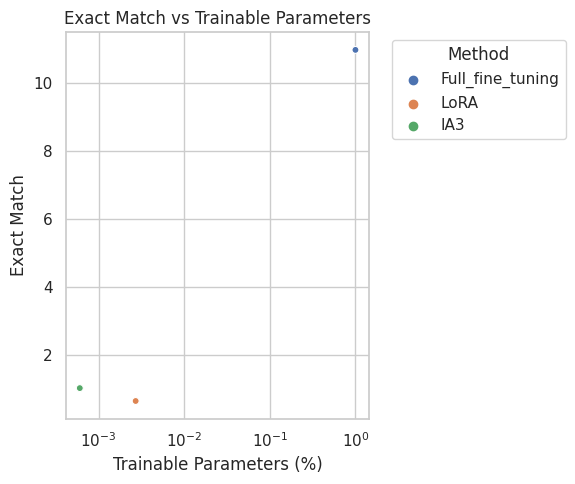

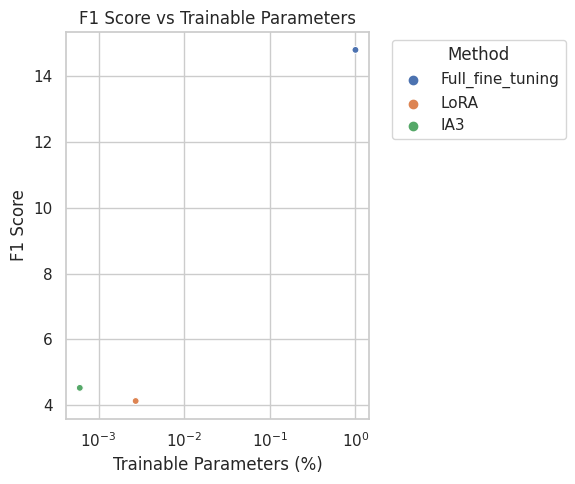

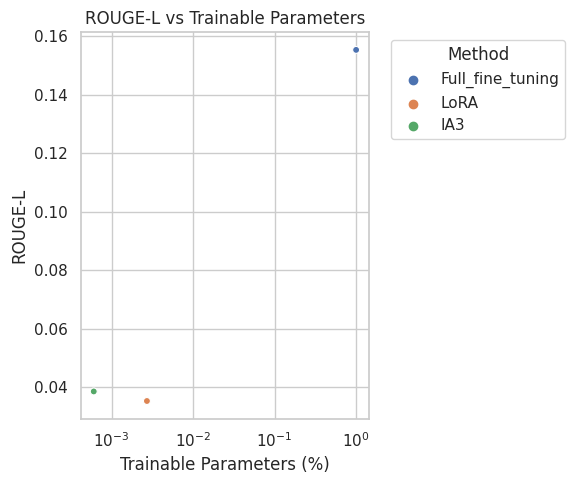

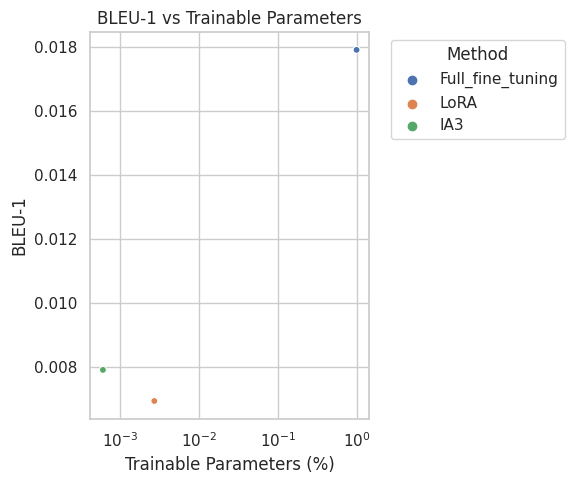

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# results` è un dizionario con i risultati
df = pd.DataFrame(results).T  # E' la trasposta, per avere i metodi come righe

sns.set(style="whitegrid")

# Plot 1: Exact Match vs Trainable Percent
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="num_trainable_percent",
    y="exact_match",
    hue=df.index,
    palette="deep",
    s=100,
    marker="."
)
plt.title("Exact Match vs Trainable Parameters")
plt.xlabel("Trainable Parameters (%)")
plt.ylabel("Exact Match")
plt.xscale("log")
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: F1 Score vs Trainable Percent
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="num_trainable_percent",
    y="f1_score",
    hue=df.index,
    palette="deep",
    s=100,
    marker="."
)
plt.title("F1 Score vs Trainable Parameters")
plt.xlabel("Trainable Parameters (%)")
plt.ylabel("F1 Score")
plt.xscale("log")
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: ROUGE-L vs Trainable Percent
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="num_trainable_percent",
    y="rouge_l",
    hue=df.index,
    palette="deep",
    s=100,
    marker="."
)
plt.title("ROUGE-L vs Trainable Parameters")
plt.xlabel("Trainable Parameters (%)")
plt.ylabel("ROUGE-L")
plt.xscale("log")
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 4: BLEU-1 vs Trainable Percent
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="num_trainable_percent",
    y="bleu_1",
    hue=df.index,
    palette="deep",
    s=100,
    marker="."
)
plt.title("BLEU-1 vs Trainable Parameters")
plt.xlabel("Trainable Parameters (%)")
plt.ylabel("BLEU-1")
plt.xscale("log")
plt.legend(title="Method", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Full fine-tuning offre i migliori risultati in termini di Exact Match (10.97), F1 (14.80), Rouge L (0.16) e Bleu 1 (0.02) ma al costo di dover aggiornare tutti i parametri.

IA3 e LoRA riducono drasticamente il numero di parametri addestrabili, mostrando però performance molto più basse.

**Effetto del Learning Rate su LoRA**

In [62]:
def train_model_lora(train_dataset, eval_dataset, tokenizer, learning_rate=1e-5):

    # Reinizializzo il modello base
    base_model = AutoModelForQuestionAnswering.from_pretrained("bert-base-uncased", config=config)
    
    # Reinizializzo LoRA
    lora_config = LoraConfig(
        r=8,
        lora_alpha=16,
        target_modules=["query", "value"],
        lora_dropout=0.1,
        bias="none",
        task_type=TaskType.QUESTION_ANS
    )
    model_lora = get_peft_model(base_model, lora_config)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"./lora_lr_{learning_rate}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.05,
        logging_dir="./logs",
        logging_steps=10,
        report_to="none",
        seed=SEED
    )

    trainer = Trainer(
        model=model_lora,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
        data_collator=default_data_collator
    )

    trainer.train()

    # Valuto i checkpoint per scegliere il migliore
    best_f1 = -1
    best_checkpoint = None
    batch_size = training_args.per_device_train_batch_size

    checkpoint_dir = f"./lora_lr_{learning_rate}"
    available_checkpoints = sorted([
        os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir)
        if d.startswith("checkpoint-")
    ])

    for ckpt_path in available_checkpoints:  
        print(f"Valuto: {ckpt_path}")
        # Carico solo i pesi LoRA
        model_ckpt = PeftModel.from_pretrained(base_model, ckpt_path, local_files_only=True)
        model_ckpt.to("cuda")

        metrics = eval(model_ckpt, original_eval_dataset)
        print(f"Checkpoint {ckpt_path} -> F1: {metrics['f1']:.4f}")

        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_checkpoint = ckpt_path

    print(f"Miglior modello: {best_checkpoint} con F1 = {best_f1:.4f}")

    # Carico il miglior modello
    model_lora = PeftModel.from_pretrained(base_model, best_checkpoint)
    model_lora.to("cuda")

    metric_result = eval(model_lora,original_test_dataset)

    print(f"Metric result: {metric_result}")
    
    peft_params = get_peft_model_state_dict(model_lora)
    num_trainable_parameters = sum(p.numel() for p in peft_params.values())
    total_parameters = sum(p.numel() for p in model_lora.parameters())

    results = {
            "learning_rate": learning_rate,
            "exact_match": metric_result['exact_match'],
            "f1_score": metric_result['f1'],
            "rouge_l": metric_result["rougeL"],
            "bleu_1": metric_result["bleu1"],
            "total_parameters": total_parameters,
            "num_trainable_parameters": num_trainable_parameters,
            "num_trainable_percent": num_trainable_parameters / total_parameters
    }

    return results

In [63]:
results = []
learning_rates = [1e-5, 2e-5, 3e-5, 5e-5]

for lr in learning_rates:
    print(f"\n Training con learning rate = {lr}")
    result = train_model_lora(train_dataset, eval_dataset, tokenizer, learning_rate=lr)
    results.append(result)

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Training con learning rate = 1e-05


/tmp/ipykernel_35/2963671017.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForQuestionAnswering`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,5.184400,5.310190
2,4.715400,4.819601
3,4.589900,4.713771


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

Checkpoint ./lora_lr_5e-05/checkpoint-2958 -> F1: 6.4839
Valuto: ./lora_lr_5e-05/checkpoint-986


100%|██████████| 438/438 [01:00<00:00,  7.23it/s]


Checkpoint ./lora_lr_5e-05/checkpoint-986 -> F1: 6.2252
Miglior modello: ./lora_lr_5e-05/checkpoint-2958 con F1 = 6.4839


100%|██████████| 265/265 [00:32<00:00,  8.09it/s]


Metric result: {'exact_match': 0.9460737937559129, 'f1': 3.39767624650729, 'rougeL': 0.0336262272452582, 'bleu1': 0.006997639849281605}


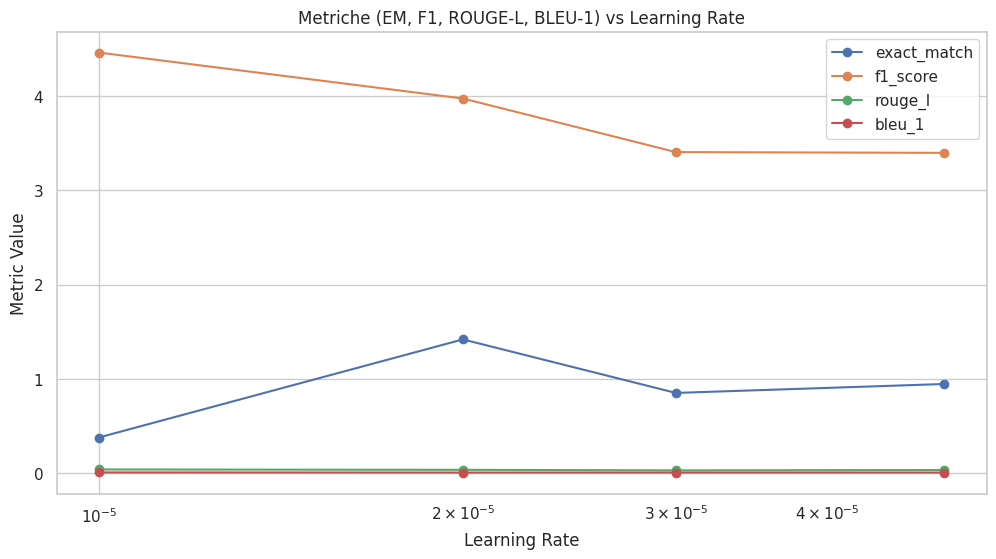

In [65]:
# Plot dei risultati
results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
for metric in ["exact_match", "f1_score", "rouge_l", "bleu_1"]:
    plt.plot(results_df["learning_rate"], results_df[metric], label=metric, marker='o')

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Metric Value")
plt.title("Metriche (EM, F1, ROUGE-L, BLEU-1) vs Learning Rate")
plt.grid(True)
plt.legend()
plt.show()

Dai risultati emerge che l'aumento del learning rate peggiora le performance del modello LoRA.
Il valore più basso testato (1e-5) ha prodotto un miglioramento delle metriche.

F1 mostra un calo quasi lineare all’aumentare del learning rate da 1e-5 a 5e-5; questo indica che il modello perde capacità di generalizzazione fine, andando probabilmente verso un overfitting locale.

Exact Match aumenta leggermente fino a 2e-5, poi cala e si stabilizza. Tuttavia i valori sono sempre molto bassi (< 1.5), quindi poco affidabili da soli.

ROUGE-L e BLEU-1 restano sempre bassi ma massimi con 1e-5, poi calano. 

Learning rate superiori portano a una perdita di precisione e capacità di generalizzazione del modello.
Quindi non conviene aumentare il learning rate ma mantenerlo a 1e-5.